## <font color='Black'> Construção de um Modelo de IA para Classificação de Imagens (Ponta a Ponta)</font>




🧠 **Contextos de aplicação:**

🔹 Varejo Inteligente - Classificar produtos automaticamente em um centro de distribuição.

🔹 Segurança - Detectar situações de risco a partir de imagens.

🔹 Indústria - Identificar defeitos em produtos.

---

**Pipeline de um Projeto de IA:**
Dados → Pré-processamento → Modelo → Treinamento → Validação → Teste → Inferência

*O valor não está no dataset — está na capacidade de aplicar o mesmo pipeline em diferentes problemas!*

Construir um modelo de Inteligência Artificial capaz de classificar imagens considerando 10 categorias: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']. Dada uma nova imagem de uma dessas categorias o modelo deve ser capaz de classificar e indicar o que é a imagem. <font color='red'>Uma imagem é uma matriz de pixels!</font>

---

## **1. Biblioteca + Dados**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# Carregar o CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Treino:", x_train.shape)
print("Teste :", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1764s 10us/step
Treino: (50000, 32, 32, 3)
Teste : (10000, 32, 32, 3)


In [3]:
# Classes das imagens
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

## **2. Visualização dos dados**

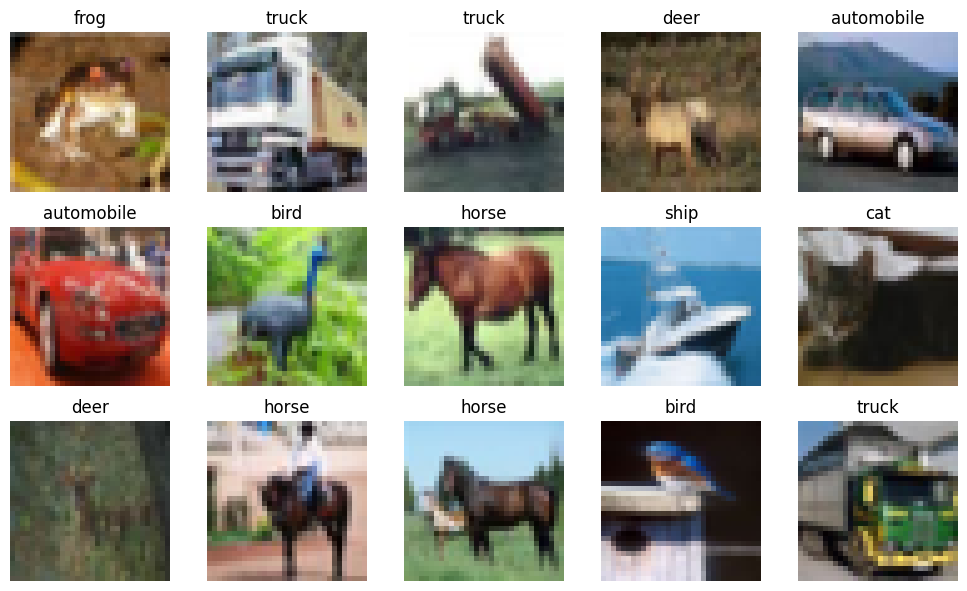

In [4]:
plt.figure(figsize=(10, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## **3. Pré-processamento**

In [5]:
print("Antes:", x_train.min(), "a", x_train.max())

# Normalização: 0–255 → 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Depois:", x_train.min(), "a", x_train.max())

Antes: 0 a 255
Depois: 0.0 a 1.0


## **4. Construção do Modelo**

In [6]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## **5. Treinamento + Validação**

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4689 - loss: 1.4731 - val_accuracy: 0.5539 - val_loss: 1.2509
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6075 - loss: 1.1188 - val_accuracy: 0.6273 - val_loss: 1.0801
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6596 - loss: 0.9764 - val_accuracy: 0.6551 - val_loss: 0.9967
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6906 - loss: 0.8927 - val_accuracy: 0.6707 - val_loss: 0.9550
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7147 - loss: 0.8224 - val_accuracy: 0.6725 - val_loss: 0.9458


## **6. Avaliação do Modelo**

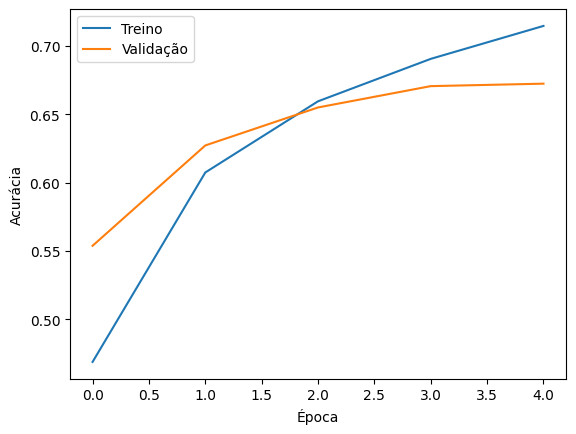

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6706 - loss: 0.9509

Acurácia no teste: 67.06%


In [8]:
# Curvas de aprendizado
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')

plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# Avaliação final
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"\nAcurácia no teste: {test_accuracy:.2%}")

### **6.1 Matriz de confusão**

A **acurácia** mostra o desempenho geral do modelo.  
A **matriz de confusão** permite analisar os acertos e erros de cada classe.

- **Diagonal principal:** classificações corretas.
- **Fora da diagonal:** classes que o modelo confundiu.

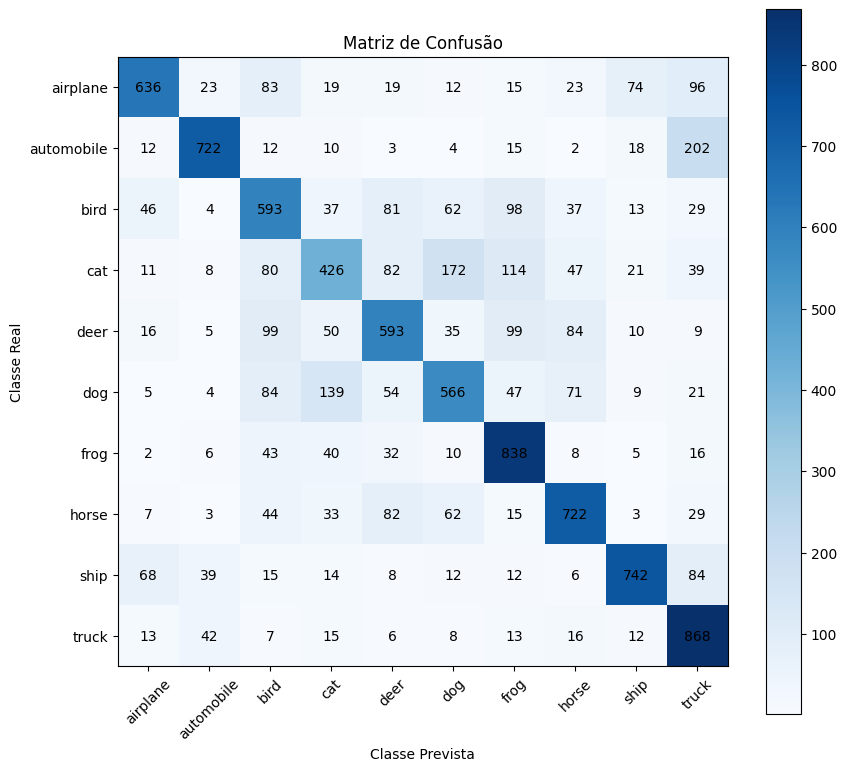

In [9]:
# Previsões para todo o conjunto de teste
y_pred = model.predict(x_test, verbose=0)

# Classe com maior probabilidade
y_pred_classes = np.argmax(y_pred, axis=1)

# Matriz de confusão
matriz_confusao = tf.math.confusion_matrix(
    y_test.flatten(),
    y_pred_classes
)

# Exibição
plt.figure(figsize=(9, 8))

plt.imshow(matriz_confusao, cmap="Blues")

plt.title("Matriz de Confusão")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.yticks(
    range(10),
    class_names
)

plt.colorbar()

# Valores dentro da matriz
for i in range(10):
    for j in range(10):
        plt.text(
            j, i,
            matriz_confusao[i, j].numpy(),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

- Quais classes o modelo mais confundiu?
- Por que essas imagens podem ser visualmente semelhantes?

## **7. Inferência com uma imagem do teste**

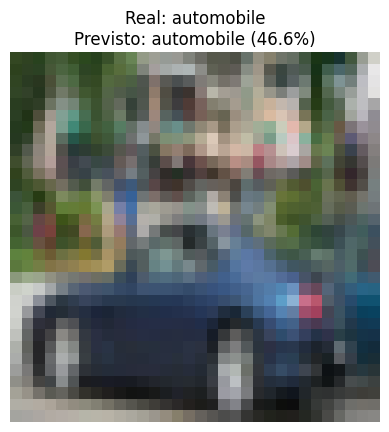

In [13]:
# Escolher uma imagem, alterando apenas o índice
indice = 122

imagem = x_test[indice]
classe_real = y_test[indice][0]

# Preparar para o modelo
imagem_modelo = np.expand_dims(imagem, axis=0)

# Fazer a previsão
previsoes = model.predict(imagem_modelo, verbose=0)

classe_prevista = np.argmax(previsoes)
confianca = np.max(previsoes)

# Mostrar resultado
plt.imshow(imagem)
plt.title(
    f"Real: {class_names[classe_real]}\n"
    f"Previsto: {class_names[classe_prevista]} ({confianca:.1%})"
)
plt.axis("off")
plt.show()

## **8. Inferência com uma imagem externa**

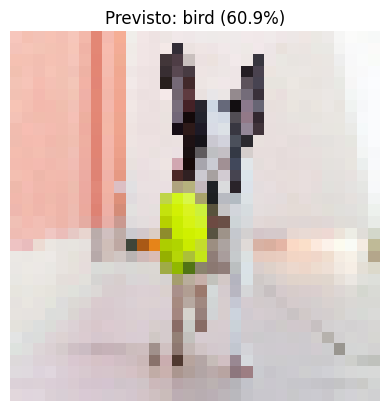

In [ ]:
# Carregar uma nova imagem
img = tf.keras.utils.load_img(
    "/content/image1.jpg",
    target_size=(32, 32)
)

# Preparar a imagem
img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Fazer a previsão
previsoes = model.predict(img_array, verbose=0)

classe_prevista = np.argmax(previsoes)
confianca = np.max(previsoes)

# Mostrar resultado
plt.imshow(img)
plt.title(
    f"Previsto: {class_names[classe_prevista]} "
    f"({confianca:.1%})"
)
plt.axis("off")
plt.show()

Se você chegou até aqui, parabéns! 🎆 🔥

**Agora explore outros datasets disponíveis no Keras, como: MNIST, Fashion-MNIST e CIFAR-100.** Observe como o mesmo pipeline pode ser adaptado para diferentes problemas.

Fim!